# Drone ground-test debug: Vicon vs onboard estimator

Compares `/vicon/<name>/<name>` (ground truth from `vicon_bridge`) against
`/<name>/est` (onboard EKF, `stateEstimate.{x,y,z,roll,pitch,yaw}`) from a
`ros2 unbag`-exported CSV pair.

**Units:** Vicon position is mm (converted to m below); Vicon orientation
(`x_rot_euler`/`y_rot_euler`/`z_rot_euler`) is radians; the onboard estimate is
already meters and degrees. Everything is converted to meters/degrees before
plotting so the two traces are directly comparable.

Export each topic with `ros2 unbag` as CSV, point `VICON_CSV`/`EST_CSV` below
at the files, and run all cells.


In [62]:
import ast
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Colorblind-safe, fixed assignment -- reused across both figures so "vicon"
# and "est" always mean the same color.
COLOR_VICON = "#0072B2"
COLOR_EST = "#D55E00"


In [86]:
# --- point these at your ros2 unbag CSV exports + the source bag ---
FLIGHT_DIR = Path("/home/noah/biodrone/bags/flight_20260723_164231")
VICON_CSV = FLIGHT_DIR / "vicon_cf09_cf09" / "vicon_cf09_cf09.csv"  # topic: /vicon/cf09/cf09
EST_CSV = FLIGHT_DIR / "cf09_est" / "cf09_est.csv"                  # topic: /cf09/est
DB3_PATH = FLIGHT_DIR / "flight_20260723_164231_0.db3"              # the source rosbag2 sqlite file


In [87]:
def _bag_recv_timestamps_ns(db3_path: Path, topic_name: str) -> list[int]:
    """Real per-message receive time (ns since epoch) for a topic, straight from
    the rosbag2 sqlite file, in chronological order.

    ros2_unbag's generic CSV export derives its `timestamp` column from the
    message's own `header.stamp` (see get_time_from_msg in
    ros2_unbag/core/utils/file_utils.py); for a message type with no header
    field at all -- vicon_receiver/msg/Position has none -- it silently falls
    back to `datetime.now()` at *export* time, not capture time. That made the
    vicon CSV's `timestamp` column show ~9 minutes after the flight actually
    happened here. The bag's own recv-time is unaffected by that bug and is
    the only reliable clock for topics without a header.
    """
    con = sqlite3.connect(db3_path)
    try:
        topic_id = con.execute(
            "SELECT id FROM topics WHERE name = ?", (topic_name,)).fetchone()[0]
        rows = con.execute(
            "SELECT timestamp FROM messages WHERE topic_id = ? ORDER BY timestamp",
            (topic_id,)).fetchall()
    finally:
        con.close()
    return [r[0] for r in rows]


def load_topic(csv_path: Path, db3_path: Path, topic_name: str) -> pd.DataFrame:
    """Load a ros2-unbag CSV export and attach the bag's real recv-time as
    `t_ns` (ns since epoch). CSV rows are written in the same chronological
    order the bag is read in, so row i lines up with the i-th recv timestamp
    for that topic -- this raises loudly if that assumption doesn't hold
    (e.g. wrong bag/CSV pairing) rather than silently misaligning the plot.
    """
    df = pd.read_csv(csv_path)
    ts_ns = _bag_recv_timestamps_ns(db3_path, topic_name)
    if len(ts_ns) != len(df):
        raise ValueError(
            f"{topic_name}: {len(df)} CSV rows but {len(ts_ns)} bag messages -- "
            "wrong bag/CSV pair, or the CSV was re-exported/edited since.")
    df["t_ns"] = ts_ns
    return df


def align_time(*dfs: pd.DataFrame) -> None:
    """Add a shared `t` column (seconds since the earliest of all given
    dataframes) so multiple topics plot on the same real-time axis. Modifies
    each dataframe in place.
    """
    t0 = min(df["t_ns"].min() for df in dfs)
    for df in dfs:
        df["t"] = (df["t_ns"] - t0) / 1e9


def explode_log_values(df: pd.DataFrame, names: list[str], column: str = "values") -> pd.DataFrame:
    """LogDataGeneric's `values` field is a float32[] array in the order given
    by the log block's `vars` -- ros2_unbag doesn't flatten arrays, so it
    lands in the CSV as one stringified-list cell per row (e.g. "[0.1, 0.2,
    ...]"). Parse it and add one named column per entry, in `names` order.
    """
    parsed = df[column].apply(ast.literal_eval)
    for i, name in enumerate(names):
        df[name] = parsed.apply(lambda v, i=i: v[i])
    return df


In [88]:
def plot_position(vicon: pd.DataFrame, est: pd.DataFrame):
    """x, y, z vs time -- one stacked subplot per axis, vicon vs onboard estimate."""
    vicon_xyz = {
        "x": vicon["x_trans"] / 1000.0,
        "y": vicon["y_trans"] / 1000.0,
        "z": vicon["z_trans"] / 1000.0,
    }
    est_xyz = {"x": est["x"], "y": est["y"], "z": est["z"]}

    fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
    for ax, axis in zip(axes, ["x", "y", "z"]):
        ax.plot(vicon["t"], vicon_xyz[axis], color=COLOR_VICON, lw=1.25, label="vicon")
        ax.plot(est["t"], est_xyz[axis], color=COLOR_EST, lw=1.25, label="est")
        ax.set_ylabel(f"{axis} (m)")
        ax.grid(True, alpha=0.25)
    axes[0].legend(loc="upper right", frameon=False)
    axes[-1].set_xlabel("time (s)")
    fig.suptitle("Position: vicon vs onboard estimate")
    fig.tight_layout()
    return fig


def _wrap_deg(x):
    """Wrap to (-180, 180]."""
    return (np.asarray(x) + 180) % 360 - 180


def plot_orientation(vicon: pd.DataFrame, est: pd.DataFrame):
    """roll, pitch, yaw vs time -- RAW, no corrections:
    vicon.{x,y,z}_rot_euler (Vicon SDK's own Euler decomposition, converted
    rad->deg) vs onboard est.{roll,pitch,yaw} (deg, exactly as logged).
    No sign flips, no re-derivation from quaternion, no unwrap -- only
    wrapped to (-180, 180] for a sane axis range.
    """
    vicon_rpy = {
        "roll": _wrap_deg(np.degrees(vicon["x_rot_euler"])),
        "pitch": _wrap_deg(np.degrees(vicon["y_rot_euler"])),
        "yaw": _wrap_deg(np.degrees(vicon["z_rot_euler"])),
    }
    est_rpy = {"roll": _wrap_deg(est["roll"]), "pitch": _wrap_deg(est["pitch"]), "yaw": _wrap_deg(est["yaw"])}

    fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
    for ax, axis in zip(axes, ["roll", "pitch", "yaw"]):
        ax.plot(vicon["t"], vicon_rpy[axis], color=COLOR_VICON, lw=1.25, label="vicon")
        ax.plot(est["t"], est_rpy[axis], color=COLOR_EST, lw=1.25, label="est")
        ax.set_ylabel(f"{axis} (deg)")
        ax.set_ylim(-185, 185)
        ax.grid(True, alpha=0.25)
    axes[0].legend(loc="upper right", frameon=False)
    axes[-1].set_xlabel("time (s)")
    fig.suptitle("Orientation: vicon vs onboard estimate (raw, no corrections)")
    fig.tight_layout()
    return fig


In [89]:
def quat_to_zyx_deg(qx, qy, qz, qw):
    """Roll/pitch/yaw (deg) via the ZYX/Tait-Bryan aerospace sequence -- the
    SAME formula the firmware uses (kalman_core.c:kalmanCoreExternalizeState),
    not Vicon SDK's own GetSegmentGlobalRotationEulerXYZ.

    Vicon's x_rot_euler/y_rot_euler/z_rot_euler come from the SDK's *XYZ*
    Euler sequence (see vicon_receiver/communicator.cpp calling
    GetSegmentGlobalRotationEulerXYZ), while stateEstimate.{roll,pitch,yaw}
    is a *ZYX* sequence. These are different, non-equivalent decompositions
    of the same orientation -- they agree near the identity but can put a
    real, non-trivial rotation's energy into a different-looking angle
    entirely (a physical roll can partly show up as "pitch" in the other
    convention). Re-deriving vicon's angles from its own quaternion
    (x_rot,y_rot,z_rot,w -- also in the Position msg) with this identical
    ZYX formula makes both sides the same quantity, for a real
    apples-to-apples check of the raw plot's roll/pitch swap.
    """
    yaw = np.degrees(np.arctan2(2*(qx*qy + qw*qz), qw**2 + qx**2 - qy**2 - qz**2))
    pitch = np.degrees(np.arcsin(np.clip(-2*(qx*qz - qw*qy), -1, 1)))
    roll = np.degrees(np.arctan2(2*(qy*qz + qw*qx), qw**2 - qx**2 - qy**2 + qz**2))
    return roll, pitch, yaw


def plot_orientation_quat(vicon: pd.DataFrame, est: pd.DataFrame):
    """Same as plot_orientation, but vicon's roll/pitch/yaw are re-derived from
    its own quaternion using the ZYX sequence (matching the firmware), instead
    of the SDK's native XYZ x_rot_euler/y_rot_euler/z_rot_euler. No sign flips
    applied to est -- isolates the Euler-sequence fix on its own.
    """
    v_roll, v_pitch, v_yaw = quat_to_zyx_deg(vicon["x_rot"], vicon["y_rot"], vicon["z_rot"], vicon["w"])
    vicon_rpy = {"roll": _wrap_deg(v_roll), "pitch": _wrap_deg(v_pitch), "yaw": _wrap_deg(v_yaw)}
    est_rpy = {"roll": _wrap_deg(est["roll"]), "pitch": _wrap_deg(est["pitch"]), "yaw": _wrap_deg(est["yaw"])}

    fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
    for ax, axis in zip(axes, ["roll", "pitch", "yaw"]):
        ax.plot(vicon["t"], vicon_rpy[axis], color=COLOR_VICON, lw=1.25, label="vicon (quat->ZYX)")
        ax.plot(est["t"], est_rpy[axis], color=COLOR_EST, lw=1.25, label="est")
        ax.set_ylabel(f"{axis} (deg)")
        ax.set_ylim(-185, 185)
        ax.grid(True, alpha=0.25)
    axes[0].legend(loc="upper right", frameon=False)
    axes[-1].set_xlabel("time (s)")
    fig.suptitle("Orientation: vicon (re-derived ZYX from quaternion) vs onboard estimate")
    fig.tight_layout()
    return fig


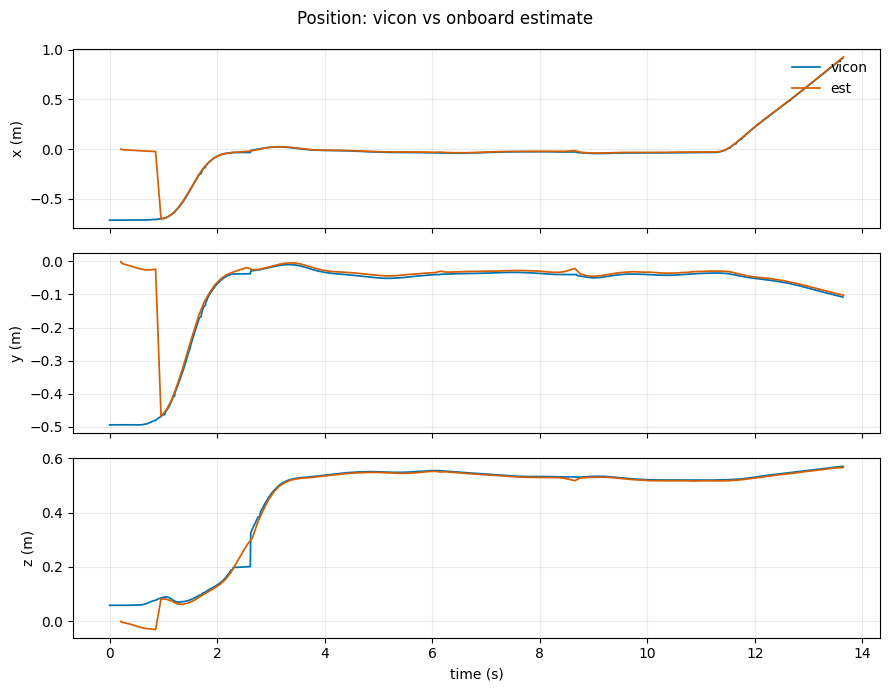

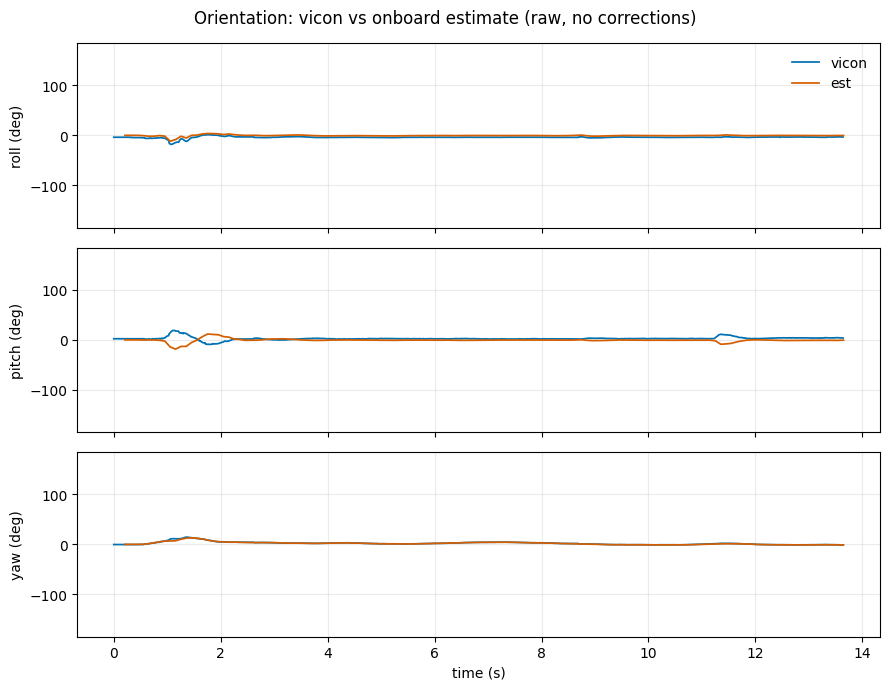

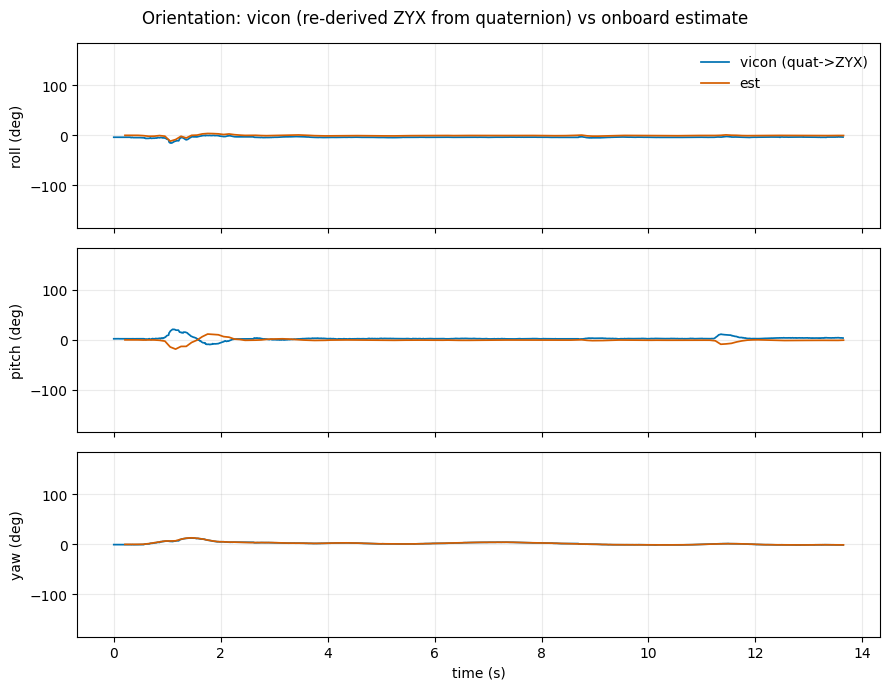

In [90]:
vicon_df = load_topic(VICON_CSV, DB3_PATH, "/vicon/cf09/cf09")

est_df = load_topic(EST_CSV, DB3_PATH, "/cf09/est")
est_df = explode_log_values(est_df, ["x", "y", "z", "roll", "pitch", "yaw"])
# no corrections applied -- raw stateEstimate.{x,y,z,roll,pitch,yaw} as logged.

align_time(vicon_df, est_df)

fig_pos = plot_position(vicon_df, est_df)
fig_rpy = plot_orientation(vicon_df, est_df)
fig_rpy_quat = plot_orientation_quat(vicon_df, est_df)
plt.show()
